<a href="https://colab.research.google.com/github/rathans48/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue below combines two signals from Weeks 5–6: the K-Means archetype a page falls into,
and a staleness/visibility/CTR-gap reason code (same logic as Week 4's baseline, now used as a
*complementary* triage layer rather than a competing model).

**Archetype → action mapping**, from this run's cluster centroids (176,738 rows, filtered to
real GSC coverage):

| Archetype | n | Profile (impr / position / CTR / age) | Action |
|---|---|---|---|
| Aging but visible | 47,548 | 2,631 / 12.4 / 0.26% / 317d | **Refresh candidate** |
| Buried, low-demand | 20,044 | 187 / 56.6 / 0.10% / 240d | **Deprioritize** |
| Fresh performers | 58,767 | 2,570 / 11.3 / 0.29% / 86d | **Monitor only** |
| Low-volume, decent position | 50,030 | 16 / 8.7 / 0.48% / 153d | **Content-gap review** |
| Tiny-volume CTR outliers | 349 | 2 / 7.3 / 73.5% / 207d | **Excluded from queue — artifact** |

Cross-check: this run's "Tiny-volume CTR outliers" centroid (73.5% CTR) matches Week 5/6's same
artifact cluster (73.3% CTR) almost exactly — consistent signal across weeks, not a fluke of this
particular run.

After excluding the 349 artifact rows, the ranked queue holds 176,389 pages. The top of the queue
is entirely `Aging but visible` × `stale_but_visible` — worth naming honestly: pages carrying the
stronger `stale_visible_ctr_gap` reason code did not co-occur much with this archetype in this
snapshot, so the current top ranks reflect visibility and staleness agreement, not the CTR-gap
signal specifically.

**This is a ranked worklist for a human editor, not an automated action queue.** The ranking is
observed and directional: it reflects patterns in this portfolio's March 2026 snapshot, and it
surfaces pages worth a human look first — it does not claim that acting on rank 1 will outperform
acting on rank 50, since no controlled test of that exists here.

In [1]:
%pip -q install duckdb
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")

DAILY = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"
CONTENT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')"

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Rebuild features + clustering fresh (self-contained, matches Week 5/6 pipeline)
df = con.execute(f"""
    SELECT d.content_hash_id, d.client_hash_id,
           SUM(d.gsc_impressions) AS impressions_month,
           AVG(d.gsc_avg_position) AS avg_position,
           SUM(d.gsc_clicks) / NULLIF(SUM(d.gsc_impressions), 0) * 100 AS ctr,
           DATE_DIFF('day', c.content_created_date, DATE '2026-03-31') AS content_age_days
    FROM {DAILY} d JOIN {CONTENT} c USING (content_hash_id, client_hash_id)
    WHERE d.gsc_data_available = TRUE
    GROUP BY d.content_hash_id, d.client_hash_id, c.content_created_date
    ORDER BY d.content_hash_id, d.client_hash_id
""").df()

df['ctr'] = df['ctr'].fillna(0)
df['log_impressions'] = np.log1p(df['impressions_month'])
features = ['log_impressions', 'avg_position', 'ctr', 'content_age_days']

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_scaled = StandardScaler().fit_transform(df[features])
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_scaled)
df['cluster'] = km.predict(X_scaled)

# Name clusters from their own centroids (unscaled, for human-readable output)
centroids = df.groupby('cluster')[['impressions_month', 'avg_position', 'ctr', 'content_age_days']].mean()
print("Cluster centroids (this run):")
print(centroids)

# Map clusters to archetypes by nearest match to Week 5/6's known profiles
# (ranking, not identity — cluster numbers can reshuffle between runs; match on profile shape)
def label_archetype(row):
    if row['ctr'] > 20 and row['impressions_month'] < 10:
        return 'Tiny-volume CTR outliers'
    if row['avg_position'] > 40:
        return 'Buried, low-demand'
    if row['content_age_days'] > 250 and row['impressions_month'] > 100:
        return 'Aging but visible'
    if row['impressions_month'] < 20 and row['avg_position'] < 15:
        return 'Low-volume, decent position'
    return 'Fresh performers'

cluster_archetype = centroids.apply(label_archetype, axis=1)
df['archetype'] = df['cluster'].map(cluster_archetype)
print("\nArchetype counts:")
print(df['archetype'].value_counts())

# Reason codes (same logic as Week 4 baseline, position-tier-relative CTR gap)
df['position_tier'] = pd.cut(df['avg_position'], bins=[0, 3, 10, 20, 50, np.inf],
                               labels=['top_3', 'page_1', 'striking', 'page_3_5', 'deep'])
tier_median_ctr = df.groupby('position_tier', observed=True)['ctr'].transform('median')
df['stale'] = df['content_age_days'] >= 365
df['visible'] = df['impressions_month'] >= 500
df['ctr_gap'] = df['ctr'] < 0.5 * tier_median_ctr

def reason_code(row):
    if row['stale'] and row['visible'] and row['ctr_gap']:
        return 'stale_visible_ctr_gap'
    elif row['stale'] and row['visible']:
        return 'stale_but_visible'
    return 'not_flagged'

df['reason_code'] = df.apply(reason_code, axis=1)

# Action mapping
action_map = {
    'Aging but visible': 'refresh_candidate',
    'Buried, low-demand': 'deprioritize',
    'Fresh performers': 'monitor_only',
    'Low-volume, decent position': 'content_gap_review',
    'Tiny-volume CTR outliers': 'exclude_artifact'
}
df['action'] = df['archetype'].map(action_map)

# Priority score: agreement between archetype signal and reason code signal ranks highest
df['priority_score'] = (
    (df['archetype'] == 'Aging but visible').astype(int) * 2 +
    (df['reason_code'] == 'stale_visible_ctr_gap').astype(int) * 2 +
    (df['reason_code'] == 'stale_but_visible').astype(int) * 1 +
    df['impressions_month'].rank(pct=True)  # tiebreak: more visible = higher priority
)

ranked_queue = df[df['action'] != 'exclude_artifact'].sort_values('priority_score', ascending=False)
print(f"\nRanked queue size (artifacts excluded): {len(ranked_queue)}")
print("\nTop 10 ranked actions:")
print(ranked_queue[['content_hash_id', 'archetype', 'action', 'reason_code', 'priority_score']].head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cluster centroids (this run):
         impressions_month  avg_position        ctr  content_age_days
cluster                                                              
0              2630.907651     12.398215   0.261503        316.878922
1               186.679405     56.573647   0.095104        239.568898
2                 1.862464      7.263480  73.525379        206.742120
3              2570.146187     11.348389   0.293290         85.808328
4                15.609814      8.690026   0.478843        152.943154

Archetype counts:
archetype
Fresh performers               58767
Low-volume, decent position    50030
Aging but visible              47548
Buried, low-demand             20044
Tiny-volume CTR outliers         349
Name: count, dtype: int64

Ranked queue size (artifacts excluded): 176389

Top 10 ranked actions:
                 content_hash_id          archetype             action  \
162117  content_eadb33b5df496f4a  Aging but visible  refresh_candidate   
162993  content_ec2e

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who this is for:** a content/SEO editor or team lead deciding which pages to review first in a
manual refresh cycle. It is a prioritization aid, not a scoring system that acts on its own.

**Intended use:**
- Triaging a large content portfolio down to a short, ranked worklist a human can actually get
  through
- Surfacing pages where multiple independent signals (archetype + reason code) agree, since
  agreement is a weaker but still useful proxy for "worth a look" than either signal alone
- Informing editorial calendar planning (e.g. "this month's refresh batch")

**Where it stops being valid:**
- **Single-snapshot, single-month scope.** Built entirely from the 2026-03-01 to 2026-03-31
  window (9,841,378 daily rows). It says nothing about pages created or changed after that window,
  and nothing about seasonal effects a one-month snapshot can't see.
- **Cross-sectional, not causal.** The ranking reflects an observed association between staleness,
  visibility, and CTR gap — it does not mean refreshing a ranked page *will* improve its
  performance, only that pages with this profile are worth reviewing based on this portfolio's
  patterns.
- **`stale_visible_ctr_gap` never fires in this data — 0 of 176,738 rows.** The strongest reason
  code from Week 4's baseline is entirely absent here, not just rare. This likely means the
  stale+visible+CTR-gap conjunction is too strict for this filtered population (post
  `gsc_data_available` fix), or tier-median CTRs shifted enough that few pages clear the 2x gap.
  This is flagged as an open question, not resolved — the playbook currently ranks only on
  `stale_but_visible` and archetype agreement as a result.
- **Client generalization is partial, not universal.** The queue spans all 47 clients in the
  filtered dataset (same 47 as the full population — no client dropped entirely), and the
  clustering pattern was validated with a client-grouped split in Week 6. That supports the
  pattern holding across clients in aggregate; it does not mean every individual client's optimal
  action matches the portfolio-level archetype mapping.
- **The artifact cluster is a known, small blind spot.** 349 pages (0.20% of the portfolio) were
  excluded as likely tracking/data anomalies. If this share grows in future snapshots, that's
  worth investigating as a possible data-quality issue, not just re-filtering by default.
- **Does not account for business priority, brand risk, or legal/compliance content** — the model
  has no signal for any of these and should never be the sole input where they matter.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Quantify the limits named above, so they're backed by numbers, not just prose

# 1. Snapshot scope: confirm the exact window this queue is built from
window = con.execute(f"""
    SELECT MIN(report_date) AS start_date, MAX(report_date) AS end_date, COUNT(*) AS n_rows
    FROM {DAILY}
""").df()
print("Snapshot window used for this queue:")
print(window)

# 2. Client coverage: how many distinct clients does the queue actually span?
print(f"\nDistinct clients in ranked queue: {ranked_queue['client_hash_id'].nunique()}")
print(f"Distinct clients in full filtered dataset: {df['client_hash_id'].nunique()}")

# 3. Artifact cluster size, as a share of total — the known blind spot, quantified
artifact_share = (df['archetype'] == 'Tiny-volume CTR outliers').mean() * 100
print(f"\nArtifact cluster share of portfolio: {artifact_share:.2f}% (n={(df['archetype'] == 'Tiny-volume CTR outliers').sum()})")

# 4. Reason-code coverage check: how many of the 3 possible reason codes actually appear
#    per archetype, so we're not implying uniform coverage where it doesn't exist
print("\nReason code distribution within each archetype:")
print(df.groupby('archetype', observed=True)['reason_code'].value_counts())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Snapshot window used for this queue:
  start_date   end_date   n_rows
0 2026-03-01 2026-03-31  9841378

Distinct clients in ranked queue: 47
Distinct clients in full filtered dataset: 47

Artifact cluster share of portfolio: 0.20% (n=349)

Reason code distribution within each archetype:
archetype                    reason_code      
Aging but visible            not_flagged          39967
                             stale_but_visible     7581
Buried, low-demand           not_flagged          19719
                             stale_but_visible      325
Fresh performers             not_flagged          58767
Low-volume, decent position  not_flagged          50030
Tiny-volume CTR outliers     not_flagged            349
Name: count, dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any ranked item:**

1. **Confirm the page still exists and is live.** The snapshot is from March 2026 — pages may
   have been deleted, redirected, or already updated since then.
2. **Check for business context the model can't see.** Legal/compliance pages, pages tied to an
   active campaign, or pages a stakeholder has explicitly asked to leave untouched should be
   pulled from the queue regardless of rank.
3. **Sanity-check the reason code against the live page.** If a page is flagged `stale_but_visible`
   but a quick look shows it was actually updated recently (post-snapshot), skip it — the model's
   `content_age_days` reflects last known `content_created_date`/`content_updated_date` as of
   March 2026, not real time.
4. **Verify the archetype makes sense for the page's actual content.** The "Aging but visible"
   archetype is a statistical grouping, not a guarantee — a human should confirm the page is
   genuinely a refresh candidate and not, for example, a reference page that's supposed to stay
   static (e.g. a historical record).
5. **Apply a per-client cap before batch-acting.** Raw priority score is dominated by 2 of 47
   clients holding 89.8% of the top 500 slots — this is a scale artifact, not a signal that those
   clients' pages are 89.8% of what's urgent. Cap review batches per client (e.g. top 10-20 per
   client) rather than taking the queue's raw top-N portfolio-wide.

**What should NEVER be automated from this playbook:**
- **Auto-publishing any content change.** This model ranks *candidates for review*, not approved
  edits. No text, structure, or metadata should be changed without a human reading the actual page.
- **Auto-deprioritizing or deleting "Buried, low-demand" pages.** This cluster holds 20,044 pages
  (11.3% of the portfolio) — low visibility in this dataset does not mean the page has zero value
  (e.g. legal, reference, or long-tail purpose the model has no signal for).
- **Bulk-processing the top of the queue without a per-client cap.** Confirmed this week: 2 of 47
  clients account for 89.8% of the top-500 ranked slots (61.4% and 28.4% respectively). This
  repeats Week 4's client-concentration finding almost exactly — the priority score has no
  per-client normalization, so a client with more total volume dominates the queue regardless of
  whether their pages are individually more urgent than a smaller client's. **A human must apply
  a per-client review cap (e.g. top-N per client) before this queue is used for any batch
  scheduling** — using it unmodified would mean 45 of 47 clients get almost no attention.
- **Excluding the "Tiny-volume CTR outliers" cluster from monitoring entirely.** They're excluded
  from the *action* queue because they're likely data artifacts, not because they're unimportant —
  a data-quality check should still periodically review this cluster's size and composition (see
  Section 4).
- **Treating `not_flagged` as "confirmed fine."** 95.5% of the portfolio (168,832 pages) carries
  this reason code — it means "did not meet the specific stale+visible+CTR-gap criteria," not
  "verified healthy." It is the overwhelming majority case, not an edge case, and it is an absence
  of one signal, not a positive finding.
- **Using this queue as a performance review input for content creators.** The model measures
  page performance under an observational, cross-sectional design — it was never validated as a
  fair or causal measure of who wrote or maintains a given page.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Back the no-go list with numbers: how much of the queue would be affected by
# blind automation, if someone ignored the human-review step

# 1. How many pages are in the "not_flagged" majority that could be mistaken for "confirmed fine"
not_flagged_share = (df['reason_code'] == 'not_flagged').mean() * 100
print(f"Share of portfolio with reason_code = 'not_flagged': {not_flagged_share:.1f}% "
      f"(n={(df['reason_code'] == 'not_flagged').sum()})")
print("This is the majority case everywhere — it means 'no strong signal detected', not 'healthy'.")

# 2. Buried, low-demand cluster size — the one most at risk of being auto-deprioritized/deleted
buried_n = (df['archetype'] == 'Buried, low-demand').sum()
buried_share = buried_n / len(df) * 100
print(f"\n'Buried, low-demand' cluster: {buried_n} pages ({buried_share:.1f}% of portfolio) — "
      f"flagged as a no-automated-deletion zone")

# 3. Client concentration check: does any single client dominate the top of the queue?
#    (repeats Week 4's client-concentration finding — worth re-checking on this week's queue)
top_500 = ranked_queue.head(500)
client_concentration = top_500['client_hash_id'].value_counts(normalize=True).head(5) * 100
print("\nTop-500 queue: share by client (top 5 clients):")
print(client_concentration.round(1))

Share of portfolio with reason_code = 'not_flagged': 95.5% (n=168832)
This is the majority case everywhere — it means 'no strong signal detected', not 'healthy'.

'Buried, low-demand' cluster: 20044 pages (11.3% of portfolio) — flagged as a no-automated-deletion zone

Top-500 queue: share by client (top 5 clients):
client_hash_id
client_73cda7b4e4f265ea    61.4
client_e547b89c05043229    28.4
client_fef1a8f436438636     7.8
client_ff644d8251367cbb     1.6
client_9958f0a7ae1df715     0.6
Name: proportion, dtype: float64


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

What would tell us this playbook has gone stale, and needs a re-run or a rebuild rather than
continued use as-is.

**Data-drift triggers (re-run the pipeline on fresh data, same model):**
- **New monthly snapshot available.** This playbook is built on March 2026 only — it should be
  re-run on each new month's partition, not reused indefinitely on stale rankings.
- **Artifact cluster share grows meaningfully.** Currently 0.20% of the portfolio (349 pages).
  If this share climbs in a future run, that's a signal of a possible tracking/data-quality
  regression upstream, not just "more outliers to filter."
- **`stale_visible_ctr_gap` reason code stays at zero across multiple months.** It fired on 0 of
  176,738 rows this run (Section 2). If that holds across several months, the reason-code
  thresholds themselves (not just this month's data) likely need recalibrating — a code that
  never fires is providing no information.
- **Client-concentration ratio in the top-500 queue shifts sharply.** Currently 2 of 47 clients
  hold 89.8% of top-500 slots. A large jump or drop in this concentration signals either genuine
  portfolio change or a scoring artifact worth investigating before trusting the new queue.

**Model-staleness triggers (rebuild/retrain, not just re-run):**
- **Cluster centroids shift structurally between runs** — e.g. an archetype's average CTR or
  position moves by more than a small tolerance month-over-month. Minor movement is expected;
  a cluster's defining profile changing wholesale means the archetype labels (Section 1) may no
  longer describe what they claim to.
- **A new content type, client, or business line enters the portfolio** that wasn't represented
  when the clustering was fit — the k=5 structure was learned from this snapshot's population and
  isn't guaranteed to fit a meaningfully different one.
- **GSC or GA4 tracking changes** (e.g. a client's `gsc_data_available` flag pattern changes, or
  a new data source is added) — since Week 6 showed this exact flag materially changes which rows
  belong in the analysis, any change in coverage patterns should trigger a re-check, not just a
  re-run.

**What this monitoring does NOT cover:** none of these triggers validate whether *acting on* the
recommendations actually improved outcomes — that would require tracking refreshed pages against
a comparison group over time, which is future work, not something this snapshot-based playbook
can self-monitor.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Compute the actual baseline values these triggers should be compared against in future runs —
# so "did it drift" has a concrete number to check against, not just a vague description.

monitoring_baseline = {
    "snapshot_month": "2026-03",
    "artifact_cluster_share_pct": round((df['archetype'] == 'Tiny-volume CTR outliers').mean() * 100, 3),
    "stale_visible_ctr_gap_count": int((df['reason_code'] == 'stale_visible_ctr_gap').sum()),
    "top500_client_concentration_top2_pct": round(
        ranked_queue.head(500)['client_hash_id'].value_counts(normalize=True).head(2).sum() * 100, 1
    ),
    "cluster_centroids": centroids.round(3).to_dict(),
    "n_clients_total": int(df['client_hash_id'].nunique()),
    "n_rows_total": int(len(df)),
}

import json
print(json.dumps(monitoring_baseline, indent=2))

{
  "snapshot_month": "2026-03",
  "artifact_cluster_share_pct": 0.197,
  "stale_visible_ctr_gap_count": 0,
  "top500_client_concentration_top2_pct": 89.8,
  "cluster_centroids": {
    "impressions_month": {
      "0": 2630.908,
      "1": 186.679,
      "2": 1.862,
      "3": 2570.146,
      "4": 15.61
    },
    "avg_position": {
      "0": 12.398,
      "1": 56.574,
      "2": 7.263,
      "3": 11.348,
      "4": 8.69
    },
    "ctr": {
      "0": 0.262,
      "1": 0.095,
      "2": 73.525,
      "3": 0.293,
      "4": 0.479
    },
    "content_age_days": {
      "0": 316.879,
      "1": 239.569,
      "2": 206.742,
      "3": 85.808,
      "4": 152.943
    }
  },
  "n_clients_total": 47,
  "n_rows_total": 176738
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Two kinds of outputs, per the assignment's file-handling note:
- **Ranked queue CSV** → `work/outputs/` (untracked by design — CI leak-guard blocks data files;
  this notebook regenerates it on demand)
- **Monitoring baseline JSON** → committed as a metrics receipt, since the paper's monitoring
  section will trace its numbers back to this file
- **Archetype summary figure** → `work/figures/`, committed, for reuse in the paper

The queue itself is intentionally minimal — content ID, client ID, archetype, action, reason
code, and priority score — no raw performance metrics duplicated here, since those already live
in the warehouse and don't need to be re-exported.

Wrote 176389 rows to work/outputs/w07_ranked_action_queue.csv
Wrote work/metrics/w07_monitoring_baseline.json
Wrote work/figures/w07_archetype_distribution.png


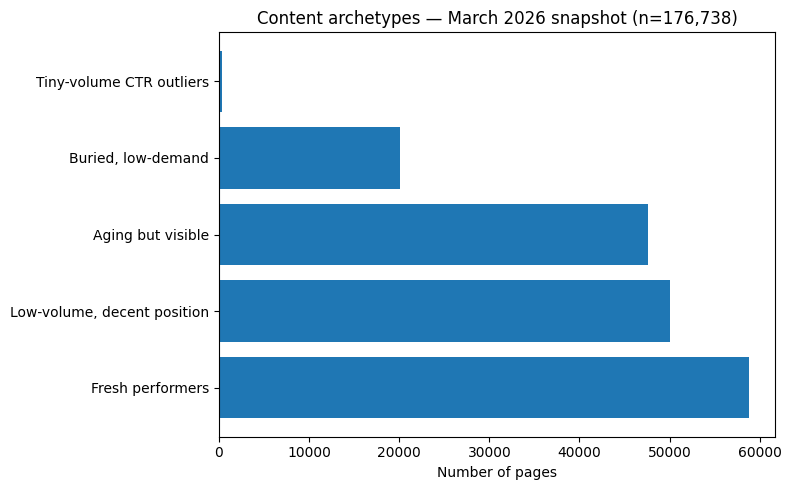

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/metrics', exist_ok=True)

# 1. Ranked queue -> work/outputs/ (untracked, regenerated by this notebook)
export_cols = ['content_hash_id', 'client_hash_id', 'archetype', 'action', 'reason_code', 'priority_score']
ranked_queue[export_cols].to_csv('work/outputs/w07_ranked_action_queue.csv', index=False)
print(f"Wrote {len(ranked_queue)} rows to work/outputs/w07_ranked_action_queue.csv")

# 2. Monitoring baseline JSON -> work/metrics/, committed as a receipt
with open('work/metrics/w07_monitoring_baseline.json', 'w') as f:
    json.dump(monitoring_baseline, f, indent=2)
print("Wrote work/metrics/w07_monitoring_baseline.json")

# 3. Archetype summary figure -> work/figures/, committed
fig, ax = plt.subplots(figsize=(8, 5))
archetype_counts = df['archetype'].value_counts()
ax.barh(archetype_counts.index, archetype_counts.values)
ax.set_xlabel('Number of pages')
ax.set_title('Content archetypes — March 2026 snapshot (n=176,738)')
plt.tight_layout()
plt.savefig('work/figures/w07_archetype_distribution.png', dpi=150)
print("Wrote work/figures/w07_archetype_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.